# Tarefa de Machine Learning

In [233]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression, RidgeCV, Ridge, LogisticRegressionCV, LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1 Questão de Regressão

# 1.1 Análise exploratória

Começamos importando o dataset de treino e assim, executamos head(), info() e describe() para entendermos melhor os dados contidos nele.

In [234]:
train_students = pd.read_csv('./regressao/train.csv')
train_students.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67


In [235]:
train_students.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    str    
 1   sex         395 non-null    str    
 2   age         395 non-null    int64  
 3   address     395 non-null    str    
 4   famsize     395 non-null    str    
 5   Pstatus     395 non-null    str    
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    str    
 9   Fjob        395 non-null    str    
 10  reason      395 non-null    str    
 11  guardian    395 non-null    str    
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    str    
 16  famsup      395 non-null    str    
 17  paid        395 non-null    str    
 18  activities  395 non-null    str    
 19  nursery     395 non-null    str    
 20 

In [236]:
train_students.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,score
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.679139
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.696912
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.330000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.330000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,10.670000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.330000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.330000


A partir disso, iremos analisar os dados contidos dentro do dataset. Para isso, começaremos com histogramas.

<Axes: xlabel='score', ylabel='Count'>

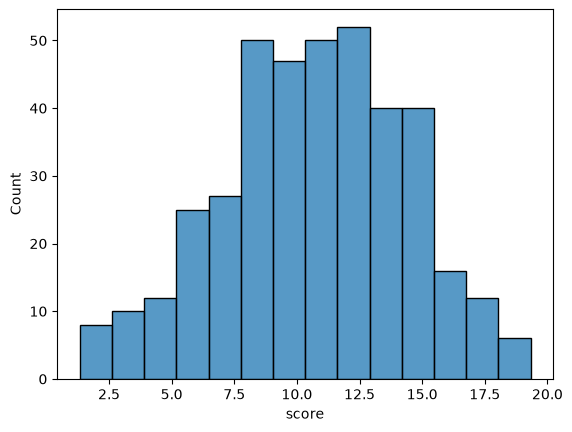

In [237]:
sns.histplot(x='score', data=train_students)

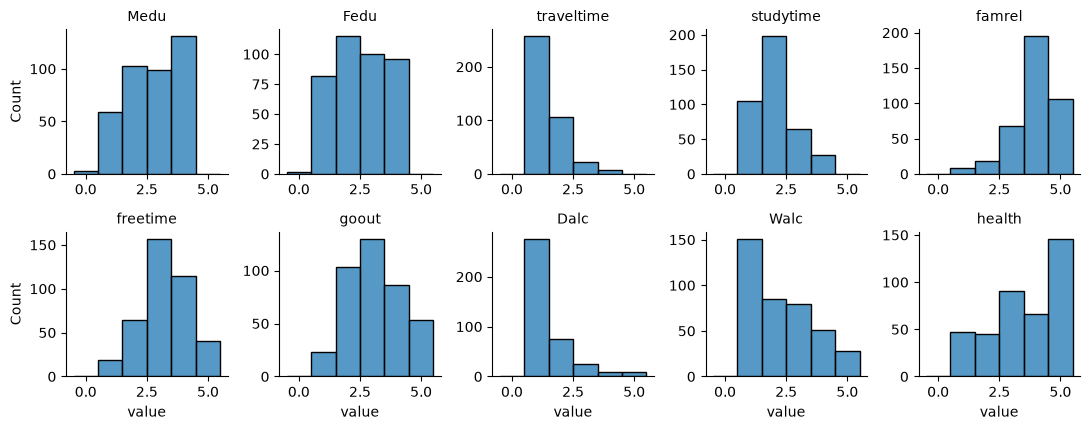

In [238]:
ordinal_cols = ["Medu", "Fedu", "traveltime", "studytime", "famrel",
                "freetime", "goout", "Dalc", "Walc", "health"]

df_long = train_students.melt(value_vars=ordinal_cols, var_name="variable", value_name="value")

g = sns.displot(
    data=df_long, x="value", col="variable", col_wrap=5,
    kind="hist", discrete=True, height=2.2,
    facet_kws=dict(sharex=False, sharey=False)
)
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(labelleft=True, labelbottom=True)

plt.show()

Agora, partiremos para os boxplots.

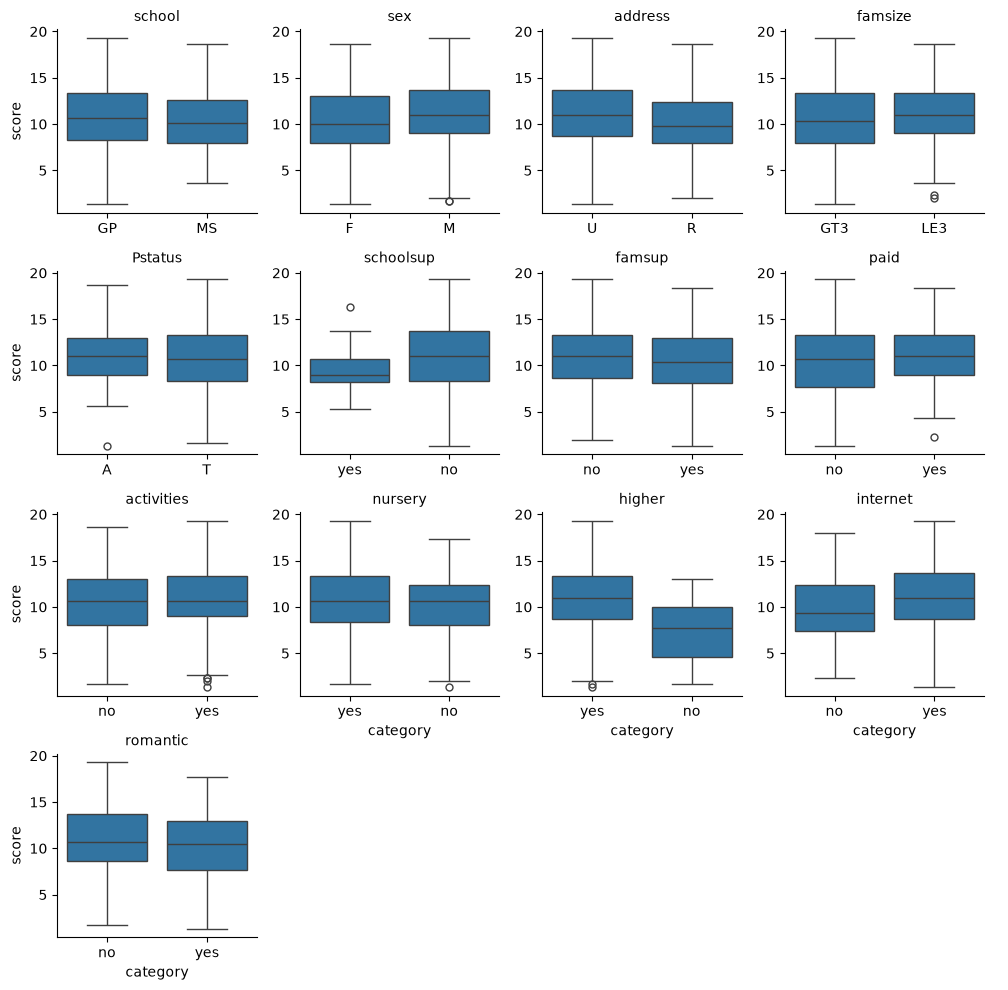

In [239]:
binary_cols = ["school", "sex", "address", "famsize", "Pstatus",
               "schoolsup", "famsup", "paid", "activities",
               "nursery", "higher", "internet", "romantic"]

df_long = train_students.melt(id_vars="score", value_vars=binary_cols,
                              var_name="variable", value_name="category")

g = sns.catplot(
    data=df_long, x="category", y="score",
    col="variable", col_wrap=4, kind="box",
    sharex=False, sharey=False, height=2.5
)
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(labelleft=True, labelbottom=True)

plt.show()

<Axes: xlabel='age', ylabel='score'>

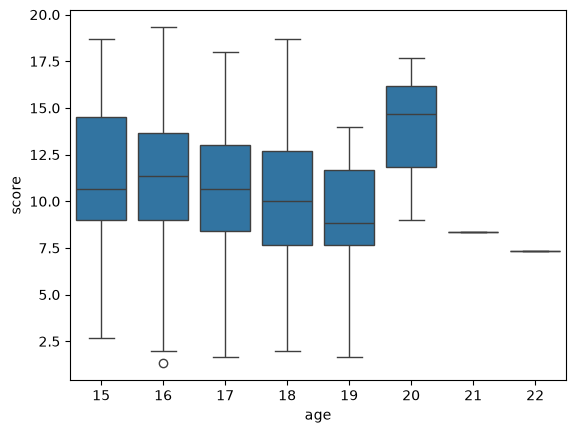

In [240]:
sns.boxplot(x='age', y='score', data=train_students)

Por fim, faremos um um heatmap com os dados.

<Axes: >

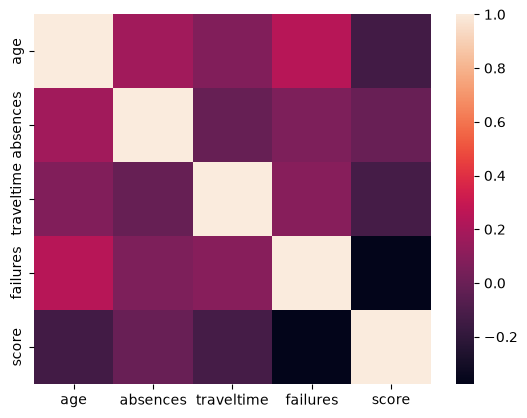

In [241]:
a = train_students[['age', 'absences', 'traveltime', 'failures', 'score']]
sns.heatmap(a.corr(numeric_only=True))

A partir do heatmap, podemos ver que os atributos não possuem uma correlação muito forte entre eles.

# 1.2 Limpeza e pré-processamento

Para realizarmos a limpeza e o pré processamento, começaremos separando os tipos de variáveis em tipos: categóricas binárias (cujo o processamento será feito transformando uma categoria em 0 e outra em 1), categóricas ordinais, categóricas nominais e dados numéricos.

In [242]:
binary_yesno = ["schoolsup", "famsup", "paid", "activities",
                 "nursery", "higher", "internet", "romantic"]

binary_other = {
    "sex":      {"M": 1, "F": 0},
    "address":  {"U": 1, "R": 0},
    "famsize":  {"GT3": 1, "LE3": 0},
    "Pstatus":  {"T": 1, "A": 0},
    "school":   {"GP": 1, "MS": 0},
}

nominal_cols = ["Mjob", "Fjob", "reason", "guardian"]

ordinal_cols = ["Medu", "Fedu", "traveltime", "studytime", "famrel",
                 "freetime", "goout", "Dalc", "Walc", "health"]

numeric_cols = ["age", "absences"]

Nessa etapa, iremos separar o nosso dataset de treino em dois: um para de fato ser usado para treino e outro para ser usado com ovalidação, visto que não temos o target do test.csv

In [243]:
y = train_students["score"]
x = train_students.drop(columns=["score"])

x_train, x_validation, y_train, y_validation = train_test_split(
    x, y, test_size=0.2, random_state=103
)

x_test = pd.read_csv("./regressao/test.csv")

Aqui, iremos terminar o tratamento de categóricas binárias (agora com aquelas do tipo "yes" ou "no")

In [244]:
def tratar_binarias(df):
    df = df.copy()
    for col in binary_yesno:
        df[col] = df[col].map({"yes": 1, "no": 0})
    for col, mapping in binary_other.items():
        df[col] = df[col].map(mapping)
    return df

x_train = tratar_binarias(x_train)
x_validation = tratar_binarias(x_validation)
x_test = tratar_binarias(x_test)

Para preparar os dados categóricos nominais, iremos utilizar o OneHotEncoding 

In [245]:
ohe = OneHotEncoder(sparse_output=False, drop="first")

ohe.fit(x_train[nominal_cols])

def aplicar_ohe(df):
    df_ohe = pd.DataFrame(ohe.transform(df[nominal_cols]), columns=ohe.get_feature_names_out(nominal_cols), index=df.index)
    return pd.concat([df.drop(columns=nominal_cols), df_ohe], axis=1)

x_train = aplicar_ohe(x_train)
x_validation = aplicar_ohe(x_validation)
x_test = aplicar_ohe(x_test)


In [246]:
x_train.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
331,1,0,17,0,1,1,2,4,1,3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
51,1,0,15,1,0,1,4,2,1,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
16,1,0,16,1,1,1,4,4,1,3,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
302,1,0,17,1,1,1,4,2,2,3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
154,1,0,17,1,1,1,4,4,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [247]:
scaler = StandardScaler()
x_train_scaled = pd.DataFrame(
    scaler.fit_transform(x_train),
    columns=x_train.columns, index=x_train.index
)
x_validation_scaled = pd.DataFrame(
    scaler.transform(x_validation),
    columns=x_validation.columns, index=x_validation.index
)
x_test_scaled = pd.DataFrame(
    scaler.transform(x_test),
    columns=x_test.columns, index=x_test.index
)

# 1.3 Inferência

Para a inferência, testaremos os modelos de Regressão Linear e Ridge.

In [248]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](39,)","[-0.19, 1.04,-0.23,..., 0.61,-0.14, 0.26]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](39,)","['school','sex','age',...,'reason_reputation','guardian_mother', 'guardian_other']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,14.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,39
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,39


In [249]:
y_validation_lr = lr.predict(x_validation)

df_check = pd.DataFrame({"real": y_validation, "previsão": y_validation_lr})

df_check.head(100)

,real,previsão
355,9.33,9.920960
153,1.67,5.556101
380,14.33,13.573267
116,12.67,13.975612
298,13.67,11.196047
...,...,...
166,10.00,8.978345
342,15.33,13.261846
130,4.00,9.743446
280,8.00,14.077861


In [250]:
rmse_lr = np.sqrt(mean_squared_error(y_validation, y_validation_lr))

print(rmse_lr)

3.4516188615498384


In [251]:
alphas = np.logspace(-5, 5, 100) 

ridge = RidgeCV(alphas=alphas, cv=5, scoring="neg_root_mean_squared_error")
ridge.fit(x_train_scaled, y_train)

print(ridge.alpha_)

148.49682622544634


In [252]:
y_validation_ridge = ridge.predict(x_validation_scaled)

df_check = pd.DataFrame({"real": y_validation, "previsão": y_validation_ridge})

df_check.head(100)

,real,previsão
355,9.33,10.469841
153,1.67,6.756072
380,14.33,12.618300
116,12.67,12.944267
298,13.67,11.318567
...,...,...
166,10.00,9.187521
342,15.33,12.609761
130,4.00,10.113908
280,8.00,12.493193


In [253]:
rmse_ridge = np.sqrt(mean_squared_error(y_validation, y_validation_ridge))

print(rmse_ridge)

3.406305641800633


In [254]:
rf = RandomForestRegressor()
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [255]:
pred_val_rf = rf.predict(x_validation)

df_check = pd.DataFrame({"real": y_validation, "previsão": pred_val_rf})

df_check.head(100)

,real,previsão
355,9.33,11.7138
153,1.67,6.8905
380,14.33,13.1225
116,12.67,13.0996
298,13.67,11.6501
...,...,...
166,10.00,9.0597
342,15.33,11.7527
130,4.00,8.1037
280,8.00,12.0395


Após aplicar os modelos, iremos aplicar o modelo que se comportou melhor no RSME, o Ridge. Para isso, juntaremos novamente os sub datasets de treino e validação (visto que eles já estão tratados) e e aplicaremos aos dados de teste. Por fim, temos como resultado a previsão para esse dataset.

In [256]:
x_full = pd.concat([x_train, x_validation], axis=0)
y_full = pd.concat([y_train, y_validation], axis=0)
x_full = scaler.fit_transform(x_full)

test = pd.read_csv('./regressao/test.csv')
test = tratar_binarias(test)          
test = aplicar_ohe(test)      
test = scaler.transform(test) 

ridge_final = Ridge(alpha=ridge.alpha_)
ridge_final.fit(x_full, y_full)

test_pred = ridge_final.predict(test)

submission1 = pd.DataFrame({
    "id": range(len(test_pred)),
    "score": test_pred
})

submission1.to_csv("./submission1.csv", index=False)
submission1.head(40)

,id,score
0,0,10.802345
1,1,11.242788
2,2,10.540113
3,3,10.966600
4,4,10.828879
5,5,10.895236
6,6,10.444058
7,7,10.040699
8,8,10.965626
9,9,9.496222


# 2 Questão de Classificação

# 2.1 Análise Exploratória

Novamente, estaremos lendo o csv de treino para a segunda questão e rodandoa as funções head(), info() e describe().

In [257]:
train2 = pd.read_csv('./classificacao/train2.csv')
train2.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [258]:
train2.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

In [259]:
train2.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Para ajudar na visualização dos gráficos, já iremos fazer uma parte da etapa de tratamento dos grupos, de modo a separar os grupos de dados.

In [260]:
train2["diagnosis_bin"] = train2["diagnosis"].map({"M": 1, "B": 0})

base_measures = [
        "radius", "texture", "perimeter", "area", "smoothness",
        "compactness", "concavity", "concave points", "symmetry",
        "fractal_dimension",
    ]


mean_cols = [f"{m}_mean" for m in base_measures]
se_cols = [f"{m}_se" for m in base_measures]
worst_cols = [f"{m}_worst" for m in base_measures]

feature_groups = {
    "mean": mean_cols,
    "se": se_cols,
    "worst": worst_cols,
}


Começamos com o plot dos histogramas do dados indivualmente.

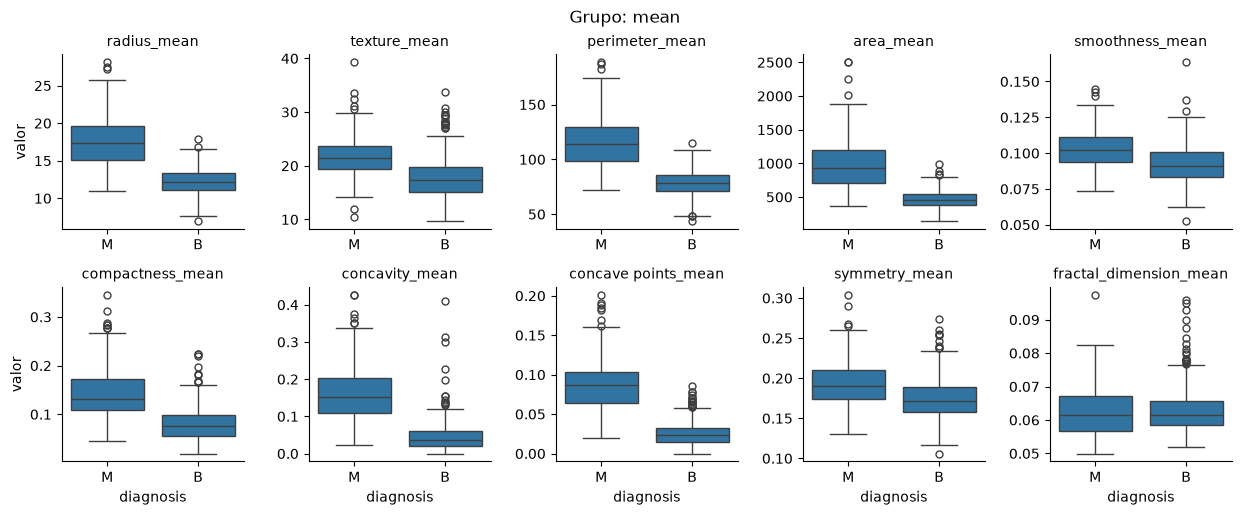

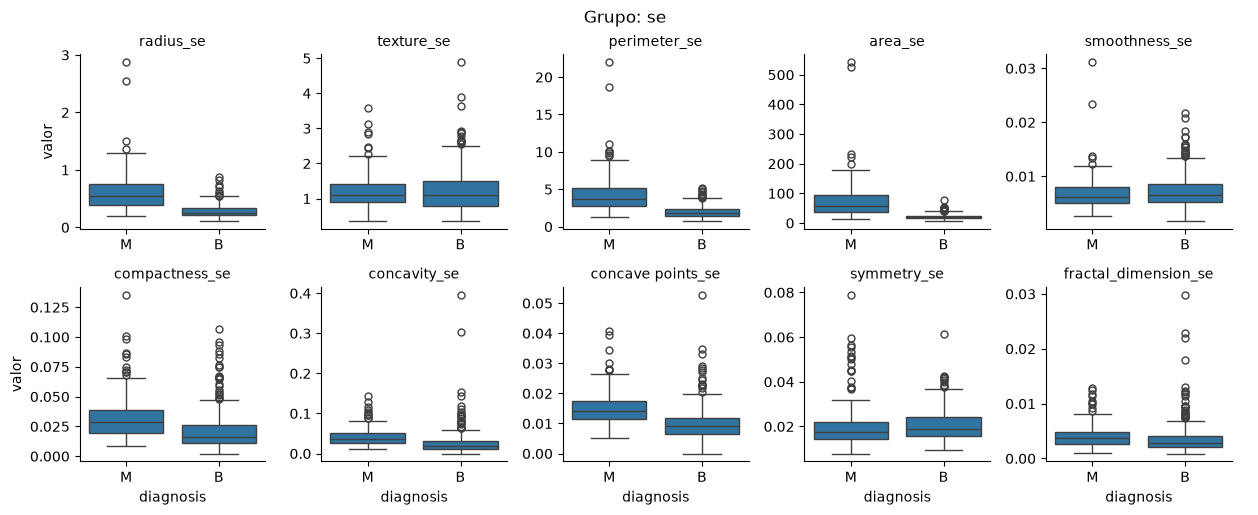

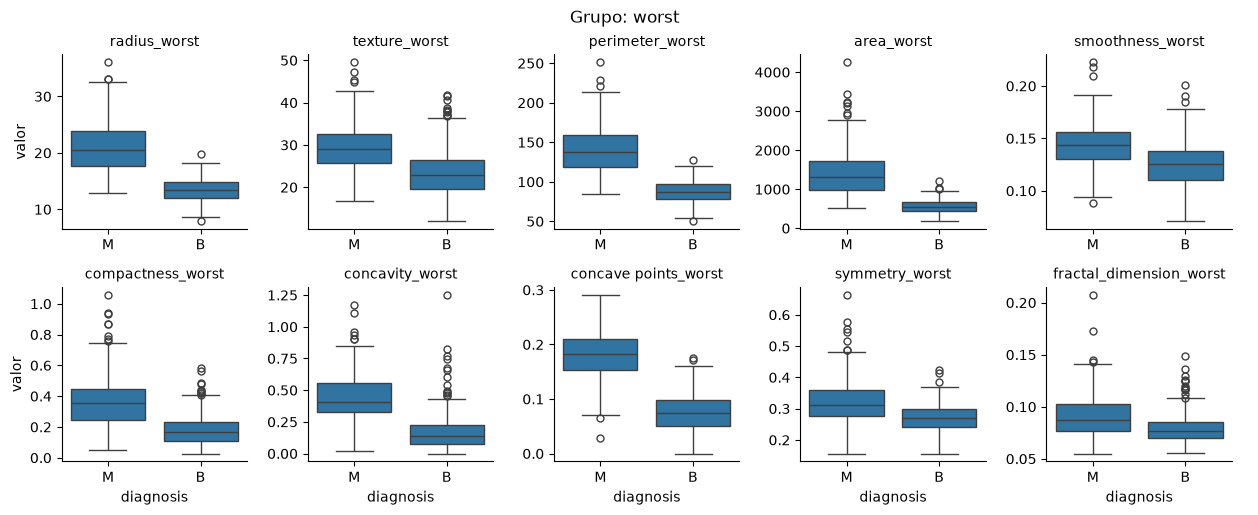

In [261]:
for nome_grupo, cols in feature_groups.items():
    df_long = train2.melt(id_vars="diagnosis", value_vars=cols,
                          var_name="feature", value_name="valor")
    g = sns.catplot(
        data=df_long, x="diagnosis", y="valor", col="feature",
        col_wrap=5, kind="box",
        sharex=False, sharey=False, height=2.5
    )
    g.set_titles("{col_name}")
    g.fig.suptitle(f"Grupo: {nome_grupo}", y=1.02)

    for ax in g.axes.flat:
        ax.tick_params(labelleft=True, labelbottom=True)

    plt.show()

Após isso, iremos fazer um ranking de dados mais correlacionados ao target (diagnosis).

In [262]:
corr_with_diagnosis = train2.drop(columns="diagnosis").corr()["diagnosis_bin"].drop("diagnosis_bin")
corr_with_diagnosis = corr_with_diagnosis.sort_values(key=abs, ascending=False)

print(corr_with_diagnosis)

concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
smoothness_se             -0.067016
fractal_dimension_mean    -0

Com esse ranking, é possível ver que temos muito mais correlações entre o target do que o exemplo passado, o que pode indicar um caso mais fácil de realizar uma predição. 

Após o plot dos histogramas e do ranking, iremos plotar um heatmap separando as variáveis por grupo.

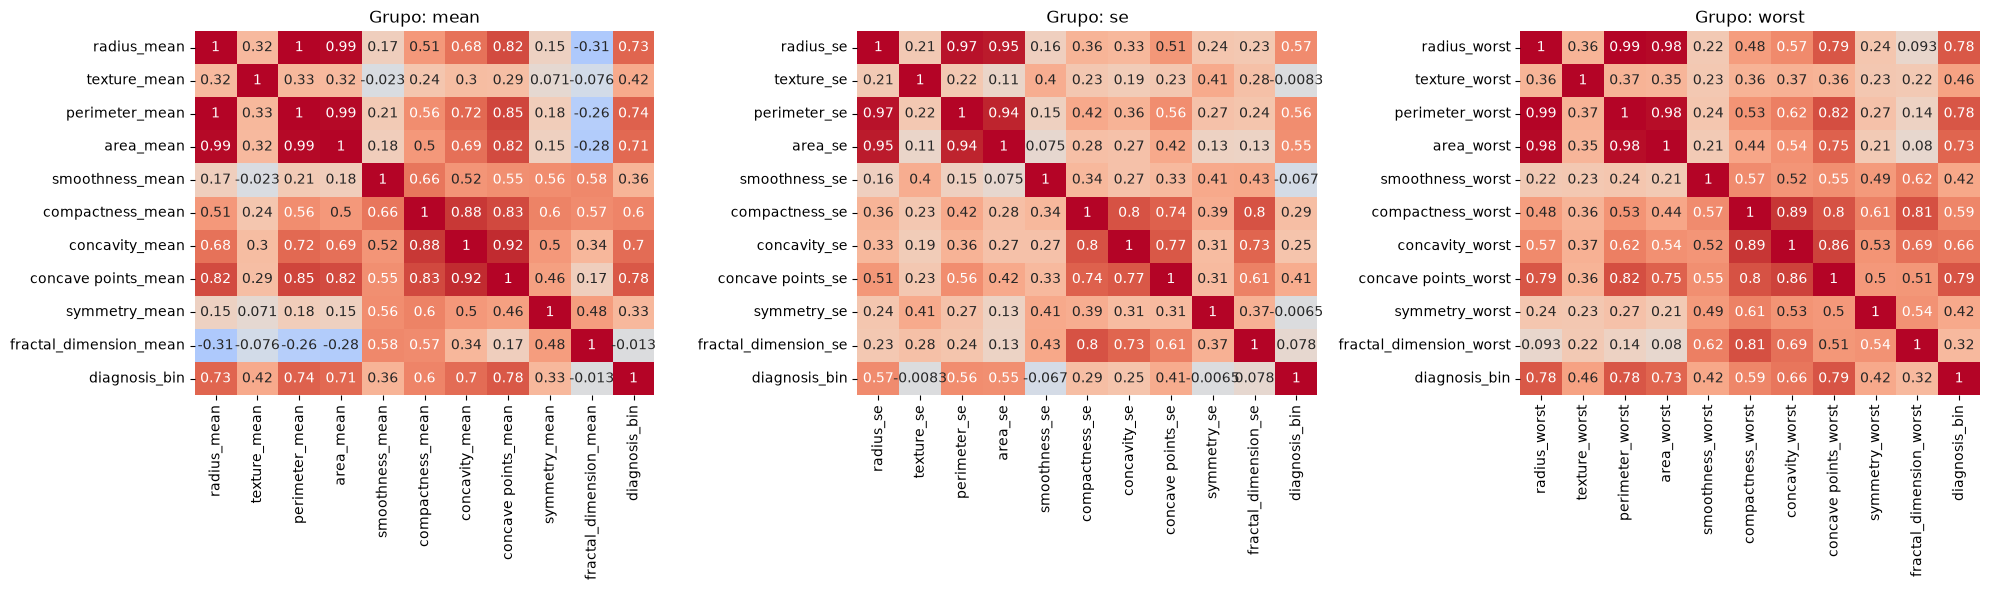

In [263]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (nome_grupo, cols) in zip(axes, feature_groups.items()):
    corr_grupo = train2[cols + ["diagnosis_bin"]].corr()
    sns.heatmap(corr_grupo, annot=True, cmap="coolwarm", center=0, ax=ax, cbar=False)
    ax.set_title(f"Grupo: {nome_grupo}")

plt.tight_layout()
plt.show()

Com o ranking, achei interessante também fazer um gráfico de dispersão usando os dois dados mais correlacionados com o diagnosis.

Text(0.5, 1.0, 'Separação de classes: perimeter_worst vs concave points_worst')

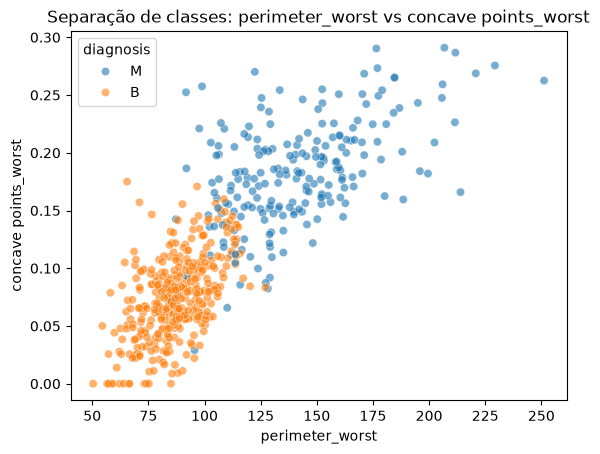

In [264]:
sns.scatterplot(data=train2, x="perimeter_worst", y="concave points_worst",
                 hue="diagnosis", alpha=0.6)
plt.title("Separação de classes: perimeter_worst vs concave points_worst")

A partir desse gráfico, temos cada vez mais evidências que esse caso parece mais clusterizado e consequentemente mais fácil de classificar. A hipótese que fica aqui é de que talvez um algoritmo linear acabe já sendo o suficiente para classificar bem.

# 2.2 Limpeza e pré-processamento

Novamente, iremos separar os datasets em treino e validação, além de realizar a normalização dos dados. Dessa vez, não usaremos o OneHotEncoding.

In [265]:
y = train2["diagnosis_bin"]
x = train2.drop(columns=["diagnosis", "diagnosis_bin"])

x_train, x_validation, y_train, y_validation = train_test_split(
    x, y, test_size=0.2, random_state=150, stratify=y
)

x_test = pd.read_csv("./classiicacao/test2.csv")

In [266]:
scaler = StandardScaler()
x_train_scaled = pd.DataFrame(
    scaler.fit_transform(x_train),
    columns=x_train.columns, index=x_train.index
)
x_validation_scaled = pd.DataFrame(
    scaler.transform(x_validation),
    columns=x_validation.columns, index=x_validation.index
)
x_test_scaled = pd.DataFrame(
    scaler.transform(x_test),
    columns=x_test.columns, index=x_test.index
)

#2.3 Inferência

Para a inferência, usaremos Regressão Logística e SVM Linear, utilizando como métrica a acurácia e também analisaremos a matriz de confusão.

In [267]:
log_reg = LogisticRegressionCV(Cs=10, cv=5, scoring="accuracy", random_state=20, max_iter=1000)
log_reg.fit(x_train_scaled, y_train)

c:\Users\luizo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\luizo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.w

,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy <accuracy_score>` is used... versionchanged:: 1.11 The default will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11.",'accuracy'
,"max_iter max_iter: int, default=100Maximum number of iterations of the optimization algorithm.",1000
,"random_state random_state: int, RandomState instance, default=NoneUsed when `solver='sag'`, 'saga' or 'liblinear' to shuffle the data.Note that this only applies to the solver and not the cross-validationgenerator. See :term:`Glossary <random_state>` for details.",20
,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add an L2 penalty term (used by default);- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features 

In [268]:
y_validation_log_reg = log_reg.predict(x_validation_scaled)

df_check = pd.DataFrame({"real": y_validation, "previsão": y_validation_log_reg})

df_check.head(100)

,real,previsão
20,0,0
483,0,0
502,0,0
201,1,1
141,1,1
...,...,...
170,0,0
387,0,0
54,1,1
427,0,0


In [269]:
acc = accuracy_score(y_validation, y_validation_log_reg)

print(acc)

0.9736842105263158


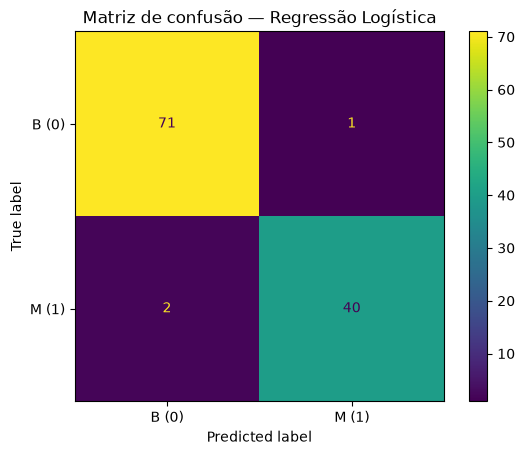

In [270]:
cm = confusion_matrix(y_validation, y_validation_log_reg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["B (0)", "M (1)"])
disp.plot()
plt.title("Matriz de confusão — Regressão Logística")
plt.show()

In [271]:
svm_linear = SVC(kernel="linear", probability=True, random_state=20)
svm_linear.fit(x_train_scaled, y_train)

c:\Users\luizo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",20
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [272]:
y_validation_svm_linear = svm_linear.predict(x_validation_scaled)


In [273]:
acc_svm_linear = accuracy_score(y_validation, y_validation_svm_linear)

print(acc_svm_linear)

0.9649122807017544


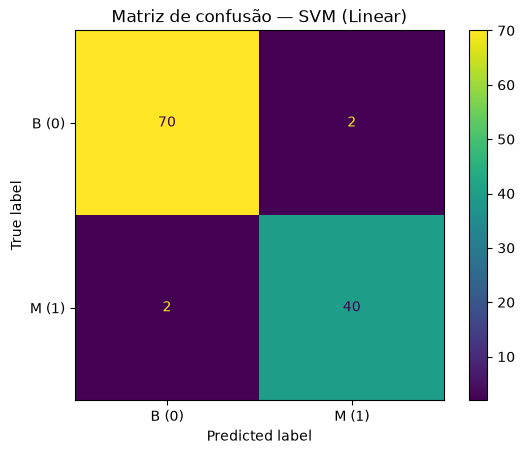

In [274]:
cm_svm = confusion_matrix(y_validation, y_validation_svm_linear)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["B (0)", "M (1)"])
disp_svm.plot()
plt.title("Matriz de confusão — SVM (Linear)")
plt.show()

Por fim, podemos ver que as acurácias ficaram muito próximas entre os dois modelos, além da matriz de confusão também ser bem parecida. Isso significa que não há como necessariamente cravar um modelo que acertaria melhor o dado de teste, visto que os dois estão com resultados muito semelhantes. Dito isso, iremos usar a Regressão Logística para realizar a classficação.

Assim como no primeiro caso, iremos concatenar o dataset e aplicar ele no modelo novamente, para aí sim utilizarmos os dados de teste.

In [275]:
x_full = pd.concat([x_train, x_validation], axis=0)
y_full = pd.concat([y_train, y_validation], axis=0)
x_full = scaler.fit_transform(x_full)

test2 = pd.read_csv('./classificacao/test2.csv')    
test2 = scaler.transform(test2) 

log_reg.fit(x_full, y_full)

test_pred = log_reg.predict(test2)

submission1 = pd.DataFrame({
    "id": range(len(test_pred)),
    "diagnosis": test_pred
})

submission1.to_csv("./submission2.csv", index=False)
submission1.head(40)

c:\Users\luizo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\luizo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.w

,id,diagnosis
0,0,0
1,1,0
2,2,0
3,3,1
4,4,0
5,5,1
6,6,0
7,7,0
8,8,0
9,9,0


# Conclusão 

De forma geral, podemos perceber que para escolhermos um modelo que seja o mais adequado possível, temos que passar por uma série de análises prévias e durante o treinamento, de modo a verificar questões como linearidade ou não dos dados, correlação entre eles e até mesmo realizar formas de amostragem mais refinadas para elegermos o modelo melhor.